In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [ ]:
!pip install openpyxl

In [ ]:
!pip install dash

In [ ]:
!pip install nbformat

In [ ]:
df = pd.read_excel("dados.xlsx", sheet_name = "Dados_gráficos ")
df

In [ ]:
df["Ano"]=[i.year for i in df["Data"]]
df

In [5]:
def serie_temporal(df, data_ini, data_fin, dias_semana, variavel, turno): 
    data = df[(df["Data"] >= data_ini) & (df["Data"] <= data_fin) & (df["Dia_semana"].isin(dias_semana)) & (df["Turno"].isin(turno))]
    
    figura, axis = plt.subplots(figsize = (15,5))
    sns.lineplot(ax = axis, data = data, x = "Data", y = variavel, hue = "Setor", palette= "flare")
    
    
    eixox = data.groupby("Data", as_index = False)["Dia_semana"].unique()
    legenda = [eixox.iloc[i,0].strftime("%d/%m/%y") + "\n" + eixox.iloc[i,1][0] for i in eixox.index]
    axis.set_xticks(ticks = eixox["Data"],labels = legenda)
    
    return figura, data

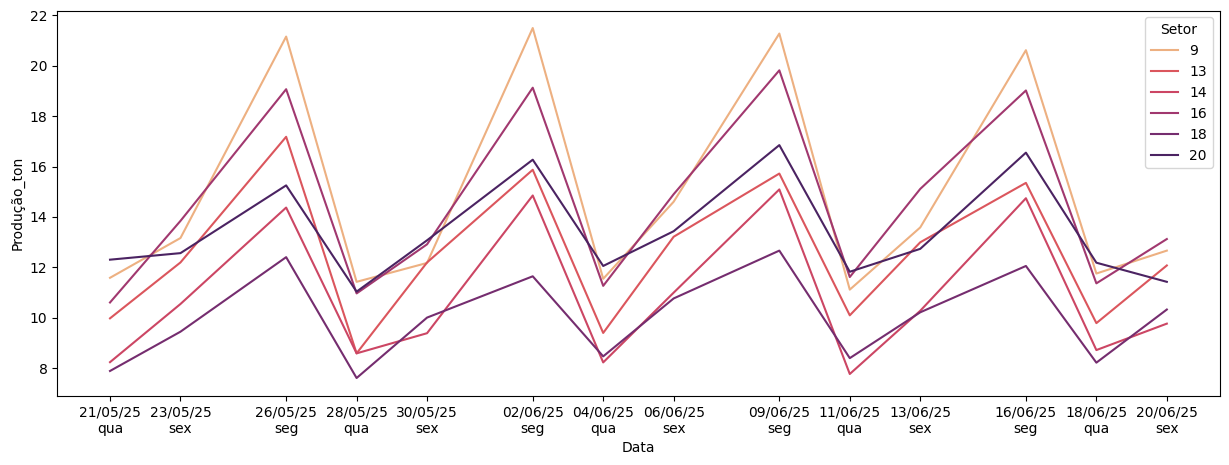

In [6]:
grafico, data = serie_temporal(df, "20/05/2025", "20/06/2025", ["seg", "qua", "sex"], "Produção_ton", ["DIURNO"])

In [ ]:
df[(df["Data"] >= "25/05/2025") & (df["Data"] <= "25/06/2025") & (df["Dia_semana"].isin(["seg"]))]

In [ ]:
eixox = data.groupby("Data", as_index = False)["Dia_semana"].unique()
legenda = [eixox.iloc[i,0].strftime("%d/%m/%y") + "\n" + eixox.iloc[i,1] for i in eixox.index]
    
    

In [187]:
var = zip(data["Data"], data["Dia_semana"])
legenda = list()
for i,j in var: 
    legenda.append(i.strftime("%d/%m") + "\n" + j)

In [2]:
from dash import dcc
import plotly.express as px

In [8]:
fig = px.line(data, x="Data", y="Produção_ton", color = "Setor")
fig.show()

In [22]:
data

,Data,Mês,Dia_mês,Dia_semana,Setor,Turno,Carro,Tempo_Coleta,Horas_coleta,Tempo_Trajeto,Tempo_Aterro,KM _COLETA,KM_TRAJETO,PRODUÇÃO,Produção_ton,Viagens,Ton/Horas,Ton/KM
466,2025-05-21,mai,21,qua,9,DIURNO,33048,05:25:00,5.416667,00:20:00,00:10:00,33,17,11580,11.58,1,2.137846,0.350909
467,2025-05-21,mai,21,qua,13,DIURNO,32050,05:41:00,5.683333,00:35:00,00:21:00,40,34,9970,9.97,1,1.754252,0.249250
468,2025-05-21,mai,21,qua,14,DIURNO,31933,04:30:00,4.500000,00:30:00,00:10:00,33,37,8230,8.23,1,1.828889,0.249394
469,2025-05-21,mai,21,qua,16,DIURNO,31912,05:30:00,5.500000,00:28:00,00:42:00,31,24,10600,10.60,1,1.927273,0.341935
470,2025-05-21,mai,21,qua,18,DIURNO,32051,05:35:00,5.583333,00:43:00,00:12:00,62,45,7880,7.88,1,1.411343,0.127097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
760,2025-06-20,jun,20,sex,13,DIURNO,32049,05:41:00,5.683333,01:22:00,00:53:00,40,57,12070,12.07,2,2.123754,0.301750
761,2025-06-20,jun,20,sex,14,DIURNO,31933,05:05:00,5.083333,00:35:00,00:45:00,36,39,9760,9.76,1,1.920000,0.271111
762,2025-06-20,jun,20,sex,16,DIURNO,32050,05:15:00,5.250000,01:13:00,00:26:00,30,61,13120,13.12,2,2.499048,0.437333
763,2025-06-20,jun,20,sex,18,DIURNO,32048,04:35:00,4.583333,01:54:00,00:33:00,52,83,10320,10.32,2,2.251636,0.198462
